# Exploratory Data Analysis — Round 1

Full EDA on **prices** and **trades** data for `ASH_COATED_OSMIUM` and `INTARIAN_PEPPER_ROOT`.

---

## 1 — Imports & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings, textwrap

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

PRODUCTS = ["ASH_COATED_OSMIUM", "INTARIAN_PEPPER_ROOT"]
COLORS   = {"ASH_COATED_OSMIUM": "#1f77b4", "INTARIAN_PEPPER_ROOT": "#ff7f0e"}
SHORT    = {"ASH_COATED_OSMIUM": "ASH", "INTARIAN_PEPPER_ROOT": "INT"}

print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
# ── Load prices ──────────────────────────────────────────────
prices_d0  = pd.read_csv("../data/prices_round_1_day_0.csv",  sep=";")
prices_dm1 = pd.read_csv("../data/prices_round_1_day_-1.csv", sep=";")
prices_dm2 = pd.read_csv("../data/prices_round_1_day_-2.csv", sep=";")

prices_d0["day"]  = 0
prices_dm1["day"] = -1
prices_dm2["day"] = -2

prices = pd.concat([prices_dm2, prices_dm1, prices_d0], ignore_index=True)

# ── Load trades ──────────────────────────────────────────────
trades_d0  = pd.read_csv("../data/trades_round_1_day_0.csv",  sep=";")
trades_dm1 = pd.read_csv("../data/trades_round_1_day_-1.csv", sep=";")
trades_dm2 = pd.read_csv("../data/trades_round_1_day_-2.csv", sep=";")

trades_d0["day"]  = 0
trades_dm1["day"] = -1
trades_dm2["day"] = -2

trades = pd.concat([trades_dm2, trades_dm1, trades_d0], ignore_index=True)

print(f"prices  : {prices.shape[0]:,} rows  |  trades : {trades.shape[0]:,} rows")

prices  : 60,000 rows  |  trades : 2,276 rows


## 2 — Data Inspection

In [3]:
print("=== PRICES columns ===")
print(prices.columns.tolist())
prices.head(3)

=== PRICES columns ===
['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1', 'bid_price_2', 'bid_volume_2', 'bid_price_3', 'bid_volume_3', 'ask_price_1', 'ask_volume_1', 'ask_price_2', 'ask_volume_2', 'ask_price_3', 'ask_volume_3', 'mid_price', 'profit_and_loss']


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,INTARIAN_PEPPER_ROOT,9992.0,17.0,NaN,NaN,NaN,NaN,10005.0,9.0,10008.0,17.0,NaN,NaN,9998.5,0.0
1,-2,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10010.0,25.0,NaN,NaN,NaN,NaN,10010.0,0.0
2,-2,100,INTARIAN_PEPPER_ROOT,9995.0,11.0,9992.0,16.0,NaN,NaN,10006.0,11.0,10008.0,16.0,NaN,NaN,10000.5,0.0


In [4]:
print("=== TRADES columns ===")
print(trades.columns.tolist())
trades.head(3)

=== TRADES columns ===
['timestamp', 'buyer', 'seller', 'symbol', 'currency', 'price', 'quantity', 'day']


,timestamp,buyer,seller,symbol,currency,price,quantity,day
0,700,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9990.0,6,-2
1,900,NaN,NaN,ASH_COATED_OSMIUM,XIRECS,9998.0,2,-2
2,1000,NaN,NaN,INTARIAN_PEPPER_ROOT,XIRECS,9995.0,7,-2


In [5]:
print("── Prices dtypes & nulls ─────────────────")
print(prices.info())
print()
print("── Trades dtypes & nulls ─────────────────")
print(trades.info())

── Prices dtypes & nulls ─────────────────
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   day              60000 non-null  int64  
 1   timestamp        60000 non-null  int64  
 2   product          60000 non-null  object 
 3   bid_price_1      57580 non-null  float64
 4   bid_volume_1     57580 non-null  float64
 5   bid_price_2      39009 non-null  float64
 6   bid_volume_2     39009 non-null  float64
 7   bid_price_3      1224 non-null   float64
 8   bid_volume_3     1224 non-null   float64
 9   ask_price_1      57649 non-null  float64
 10  ask_volume_1     57649 non-null  float64
 11  ask_price_2      39083 non-null  float64
 12  ask_volume_2     39083 non-null  float64
 13  ask_price_3      1214 non-null   float64
 14  ask_volume_3     1214 non-null   float64
 15  mid_price        60000 non-null  float64
 16  profit_and_loss

In [6]:
print("Products in prices:", prices["product"].unique())
print("Products in trades:", trades["symbol"].unique())
print()
print("Days in prices:", sorted(prices["day"].unique()))
print("Days in trades:", sorted(trades["day"].unique()))
print()
for d in sorted(prices["day"].unique()):
    sub = prices[prices["day"] == d]
    print(f"  Day {d:>2d}:  ts range [{sub['timestamp'].min()}, {sub['timestamp'].max()}]  "
          f"rows={len(sub):,}")

Products in prices: ['INTARIAN_PEPPER_ROOT' 'ASH_COATED_OSMIUM']
Products in trades: ['ASH_COATED_OSMIUM' 'INTARIAN_PEPPER_ROOT']

Days in prices: [np.int64(-2), np.int64(-1), np.int64(0)]
Days in trades: [np.int64(-2), np.int64(-1), np.int64(0)]

  Day -2:  ts range [0, 999900]  rows=20,000
  Day -1:  ts range [0, 999900]  rows=20,000
  Day  0:  ts range [0, 999900]  rows=20,000


In [7]:
# Null / missing summary
print("── Prices null counts ──")
print(prices.isnull().sum()[prices.isnull().sum() > 0])
print()
print("── Trades null counts ──")
print(trades.isnull().sum()[trades.isnull().sum() > 0])

── Prices null counts ──
bid_price_1      2420
bid_volume_1     2420
bid_price_2     20991
bid_volume_2    20991
bid_price_3     58776
bid_volume_3    58776
ask_price_1      2351
ask_volume_1     2351
ask_price_2     20917
ask_volume_2    20917
ask_price_3     58786
ask_volume_3    58786
dtype: int64

── Trades null counts ──
buyer     2276
seller    2276
dtype: int64


## 3 — Feature Engineering

In [8]:
# ── Detect column naming convention automatically ────────────
cols = prices.columns.tolist()

# Try to find best bid / ask price columns
def _find_col(patterns):
    for p in patterns:
        for c in cols:
            if p in c.lower():
                return c
    return None

bid1_col = _find_col(["bid_price_1", "bid_price1", "best_bid"])
ask1_col = _find_col(["ask_price_1", "ask_price1", "best_ask"])
bidv1_col = _find_col(["bid_volume_1", "bid_vol_1", "bid_vol1"])
askv1_col = _find_col(["ask_volume_1", "ask_vol_1", "ask_vol1"])

print(f"Detected: bid1={bid1_col}  ask1={ask1_col}  bidv1={bidv1_col}  askv1={askv1_col}")

# ── Compute derived columns ──────────────────────────────────
if bid1_col and ask1_col:
    prices["mid_price"] = (prices[bid1_col] + prices[ask1_col]) / 2
    prices["spread"]    = prices[ask1_col] - prices[bid1_col]
    prices["spread_bps"] = prices["spread"] / prices["mid_price"] * 10_000
elif "mid_price" not in prices.columns:
    print("⚠ Could not compute mid_price — check column names.")

if bidv1_col and askv1_col:
    prices["volume_imbalance"] = (
        prices[bidv1_col].fillna(0) - prices[askv1_col].abs().fillna(0)
    )
    total = prices[bidv1_col].fillna(0) + prices[askv1_col].abs().fillna(0)
    prices["imbalance_ratio"] = prices["volume_imbalance"] / total.replace(0, np.nan)

# ── Mid-price returns per product ────────────────────────────
if "mid_price" in prices.columns:
    prices = prices.sort_values(["product", "day", "timestamp"]).reset_index(drop=True)
    prices["mid_return"] = prices.groupby(["product", "day"])["mid_price"].pct_change()
    prices["mid_diff"]   = prices.groupby(["product", "day"])["mid_price"].diff()

prices.head(3)

Detected: bid1=bid_price_1  ask1=ask_price_1  bidv1=bid_volume_1  askv1=ask_volume_1


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,...,ask_price_3,ask_volume_3,mid_price,profit_and_loss,spread,spread_bps,volume_imbalance,imbalance_ratio,mid_return,mid_diff
0,-2,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10010.0,...,NaN,NaN,NaN,0.0,NaN,NaN,-25.0,-1.0,NaN,NaN
1,-2,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,...,NaN,NaN,10000.0,0.0,16.0,16.0,0.0,0.0,NaN,NaN
2,-2,200,ASH_COATED_OSMIUM,9992.0,15.0,9989.0,30.0,NaN,NaN,10008.0,...,NaN,NaN,10000.0,0.0,16.0,16.0,0.0,0.0,0.0,0.0


## 4 — Summary Statistics

In [9]:
numeric_cols = [c for c in ["mid_price", "spread", "spread_bps",
                             "volume_imbalance", "imbalance_ratio",
                             "mid_return"] if c in prices.columns]

summary = prices.groupby("product")[numeric_cols].describe().T
summary

product                 ASH_COATED_OSMIUM  INTARIAN_PEPPER_ROOT
mid_price        count       2.764400e+04          27688.000000
                 mean        1.000021e+04          11502.316112
                 std         4.858191e+00            866.151783
                 min         9.981500e+03           9998.500000
                 25%         9.997000e+03          10751.000000
                 50%         1.000050e+04          11504.500000
                 75%         1.000300e+04          12252.625000
                 max         1.001750e+04          13000.500000
spread           count       2.764400e+04          27688.000000
                 mean        1.617523e+01             13.046699
                 std         2.570999e+00              2.627145
                 min         5.000000e+00              2.000000
                 25%         1.600000e+01             12.000000
                 50%         1.600000e+01             13.000000
                 75%         1.800000e+01             14.000000
                 max         2.200000e+01             21.000000
spread_bps       count       2.764400e+04          27688.000000
                 mean        1.617485e+01             11.347048
                 std         2.570836e+00              2.136697
                 min         4.995255e+00              1.540832
                 25%         1.599520e+01             10.689251
                 50%         1.600160e+01             11.029412
                 75%         1.799280e+01             12.959225
                 max         2.199560e+01             16.924685
volume_imbalance count       3.000000e+04          30000.000000
                 mean       -4.186667e-02             -0.003867
                 std         8.156539e+00              6.393602
                 min        -3.000000e+01            -25.000000
                 25%         0.000000e+00              0.000000
                 50%         0.000000e+00              0.000000
                 75%         0.000000e+00              0.000000
                 max         3.000000e+01             25.000000
imbalance_ratio  count       2.995100e+04          29946.000000
                 mean       -1.558578e-03             -0.001059
                 std         3.568581e-01              0.331154
                 min        -1.000000e+00             -1.000000
                 25%         0.000000e+00              0.000000
                 50%         0.000000e+00              0.000000
                 75%         0.000000e+00              0.000000
                 max         1.000000e+00              1.000000
mid_return       count       2.999400e+04          29997.000000
                 mean        4.219817e-08              0.000009
                 std         1.854588e-04              0.000146
                 min        -1.098956e-03             -0.000918
                 25%        -9.996002e-05              0.000000
                 50%         0.000000e+00              0.000000
                 75%         9.996002e-05              0.000047
                 max         1.100440e-03              0.000976

In [10]:
# Per-day summary
for prod in PRODUCTS:
    sub = prices[prices["product"] == prod]
    if sub.empty:
        continue
    print(f"\n{'='*60}")
    print(f"  {prod}")
    print(f"{'='*60}")
    for d in sorted(sub["day"].unique()):
        ds = sub[sub["day"] == d]
        if "mid_price" in ds.columns:
            print(f"  Day {d:>2d}:  mid [{ds['mid_price'].min():.2f}, {ds['mid_price'].max():.2f}]  "
                  f"mean={ds['mid_price'].mean():.2f}  std={ds['mid_price'].std():.4f}  "
                  f"n={len(ds):,}")
        if "spread" in ds.columns:
            print(f"           spread  mean={ds['spread'].mean():.4f}  "
                  f"median={ds['spread'].median():.4f}  max={ds['spread'].max():.4f}")


  ASH_COATED_OSMIUM
  Day -2:  mid [9984.50, 10012.00]  mean=9998.16  std=4.7263  n=10,000
           spread  mean=16.1498  median=16.0000  max=21.0000
  Day -1:  mid [9986.50, 10013.50]  mean=10000.83  std=3.8254  n=10,000
           spread  mean=16.1913  median=16.0000  max=21.0000
  Day  0:  mid [9981.50, 10017.50]  mean=10001.62  std=5.2218  n=10,000
           spread  mean=16.1845  median=16.0000  max=22.0000

  INTARIAN_PEPPER_ROOT
  Day -2:  mid [9998.50, 11001.50]  mean=10500.57  std=287.9324  n=10,000
           spread  mean=11.9948  median=12.0000  max=18.0000
  Day -1:  mid [10998.00, 12001.00]  mean=11501.41  std=287.6403  n=10,000
           spread  mean=13.0123  median=13.0000  max=19.0000
  Day  0:  mid [11998.50, 13000.50]  mean=12500.96  std=288.1916  n=10,000
           spread  mean=14.1287  median=14.0000  max=21.0000


In [11]:
# Trade-level summary
if "price" in trades.columns and "quantity" in trades.columns:
    trades["notional"] = trades["price"] * trades["quantity"].abs()
    trade_summary = trades.groupby(["symbol", "day"]).agg(
        n_trades  = ("price", "count"),
        avg_price = ("price", "mean"),
        avg_qty   = ("quantity", lambda x: x.abs().mean()),
        total_vol = ("quantity", lambda x: x.abs().sum()),
        total_notional = ("notional", "sum"),
    )
    display(trade_summary)
else:
    print("Trade columns:", trades.columns.tolist())

n_trades     avg_price   avg_qty  total_vol  \
symbol               day                                                
ASH_COATED_OSMIUM    -2        429   9998.200466  5.151515       2210   
                     -1        425  10000.774118  5.235294       2225   
                      0        411  10001.734793  5.250608       2158   
INTARIAN_PEPPER_ROOT -2        344  10495.700581  5.072674       1745   
                     -1        335  11503.086567  5.244776       1757   
                      0        332  12525.126506  5.204819       1728   

                          total_notional  
symbol               day                  
ASH_COATED_OSMIUM    -2       22096161.0  
                     -1       22251884.0  
                      0       21583549.0  
INTARIAN_PEPPER_ROOT -2       18305887.0  
                     -1       20199633.0  
                      0       21634202.0

## 5 — Fair-Price Estimators

Five methods computed row-by-row from the order-book snapshot.

In [12]:
# ── Vectorised fair-price estimators ─────────────────────────
# (work directly on the DataFrame — no OrderDepth objects needed)

def _bb(df):
    """Best bid price column (highest-numbered level 1)."""
    return df[bid1_col] if bid1_col else np.nan

def _ba(df):
    return df[ask1_col] if ask1_col else np.nan


def fair_mid(df):
    """Simple mid of best bid / best ask."""
    return (_bb(df) + _ba(df)) / 2


def fair_microprice(df):
    """Microprice: weight best bid/ask by opposite side's volume."""
    bb, ba = _bb(df), _ba(df)
    bv = df[bidv1_col].abs() if bidv1_col else 1
    av = df[askv1_col].abs() if askv1_col else 1
    return (bb * av + ba * bv) / (bv + av)



def fair_wall_mid(df):
    pass


def fair_vwap(df):
    """VWAP across all visible bid/ask levels."""
    df_cop = df.copy()
    df_cop.replace(np.nan, 0, inplace = True)

    bid_cols  = sorted([c for c in df.columns if 'bid_price' in c.lower()])
    ask_cols  = sorted([c for c in df.columns if 'ask_price' in c.lower()])
    bidv_cols = sorted([c for c in df.columns if 'bid_volume' in c.lower() or 'bid_vol' in c.lower()])
    askv_cols = sorted([c for c in df.columns if 'ask_volume' in c.lower() or 'ask_vol' in c.lower()])

    n = min(len(bid_cols), len(bidv_cols), len(ask_cols), len(askv_cols))
    if n == 0:
        return fair_mid(df)
    

    
    bid_num = sum(df_cop[bid_cols[i]] * df_cop[bidv_cols[i]].abs() for i in range(n))
    bid_den = sum(df_cop[bidv_cols[i]].abs() for i in range(n))
    ask_num = sum(df_cop[ask_cols[i]] * df_cop[askv_cols[i]].abs() for i in range(n))
    ask_den = sum(df_cop[askv_cols[i]].abs() for i in range(n))


    bid_vwap = bid_num / bid_den.replace(0, np.nan)
    ask_vwap = ask_num / ask_den.replace(0, np.nan)
    return (bid_vwap + ask_vwap) / 2


# ── Attach all estimators ────────────────────────────────────
if bid1_col and ask1_col:
    prices["fair_mid"]        = fair_mid(prices)
    prices["fair_microprice"] = fair_microprice(prices)
    prices["fair_vwap"]       = fair_vwap(prices)
    print("Fair prices computed ✓")
else:
    print("⚠ Skipping fair price computation — bid/ask columns not found.")

prices[["product", "timestamp", "day", "mid_price",
        "fair_mid", "fair_microprice", "fair_vwap"]].head(5)

Fair prices computed ✓


,product,timestamp,day,mid_price,fair_mid,fair_microprice,fair_vwap
0,ASH_COATED_OSMIUM,0,-2,NaN,NaN,NaN,NaN
1,ASH_COATED_OSMIUM,100,-2,10000.0,10000.0,10000.0,10000.857143
2,ASH_COATED_OSMIUM,200,-2,10000.0,10000.0,10000.0,9999.666667
3,ASH_COATED_OSMIUM,300,-2,10000.0,10000.0,10000.0,9999.666667
4,ASH_COATED_OSMIUM,400,-2,10000.0,10000.0,10000.0,10000.571429


## 6 — Price Visualisation

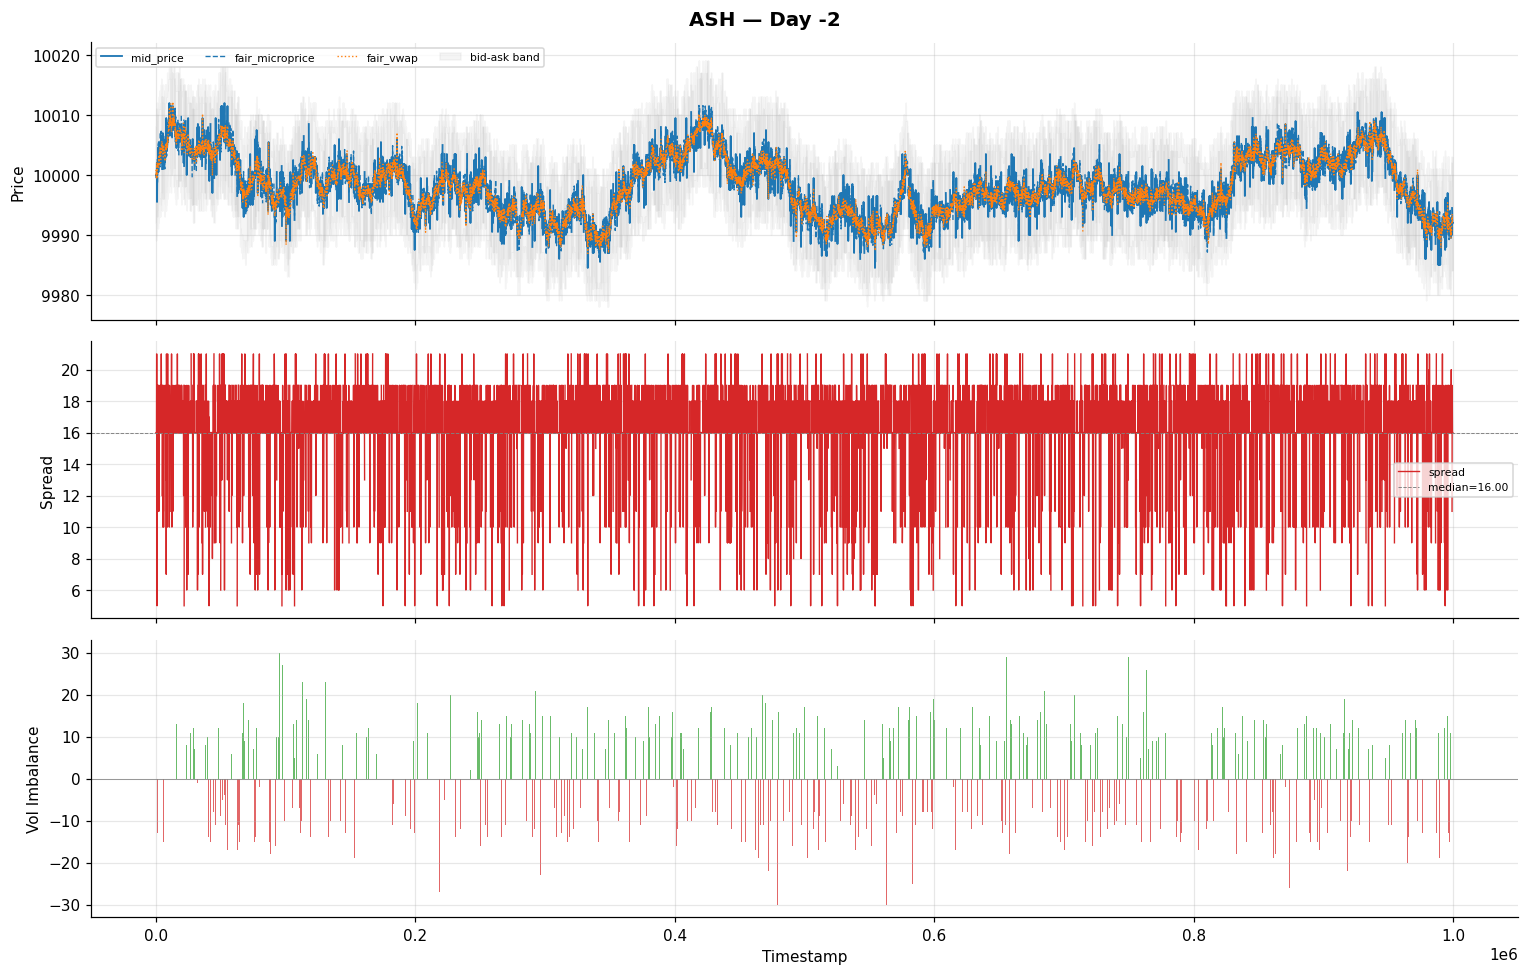

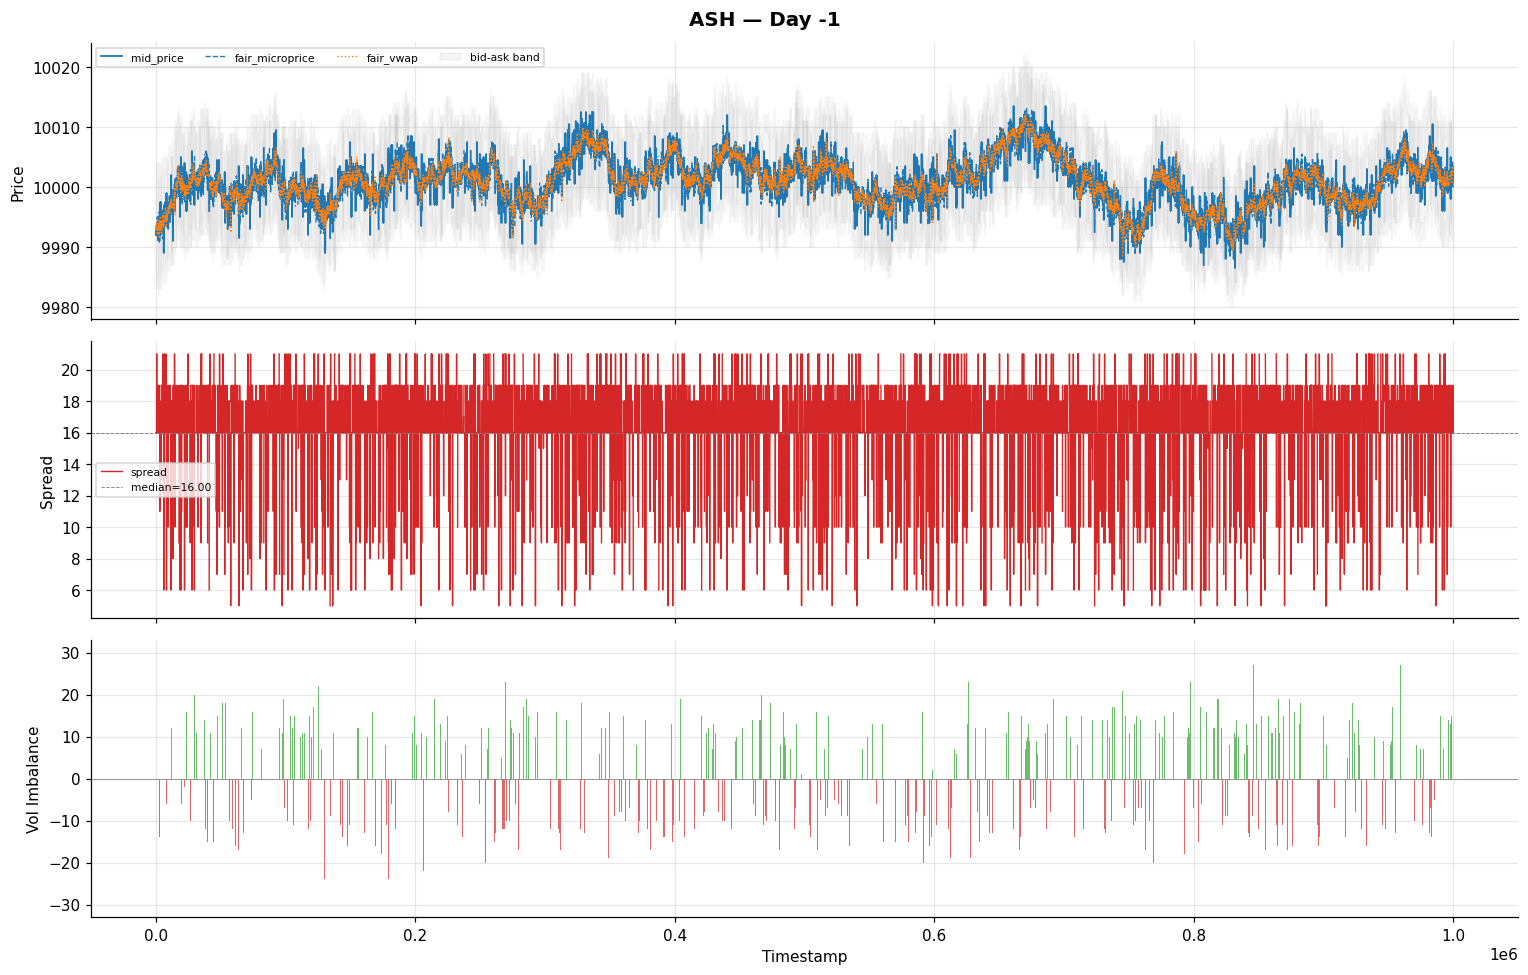

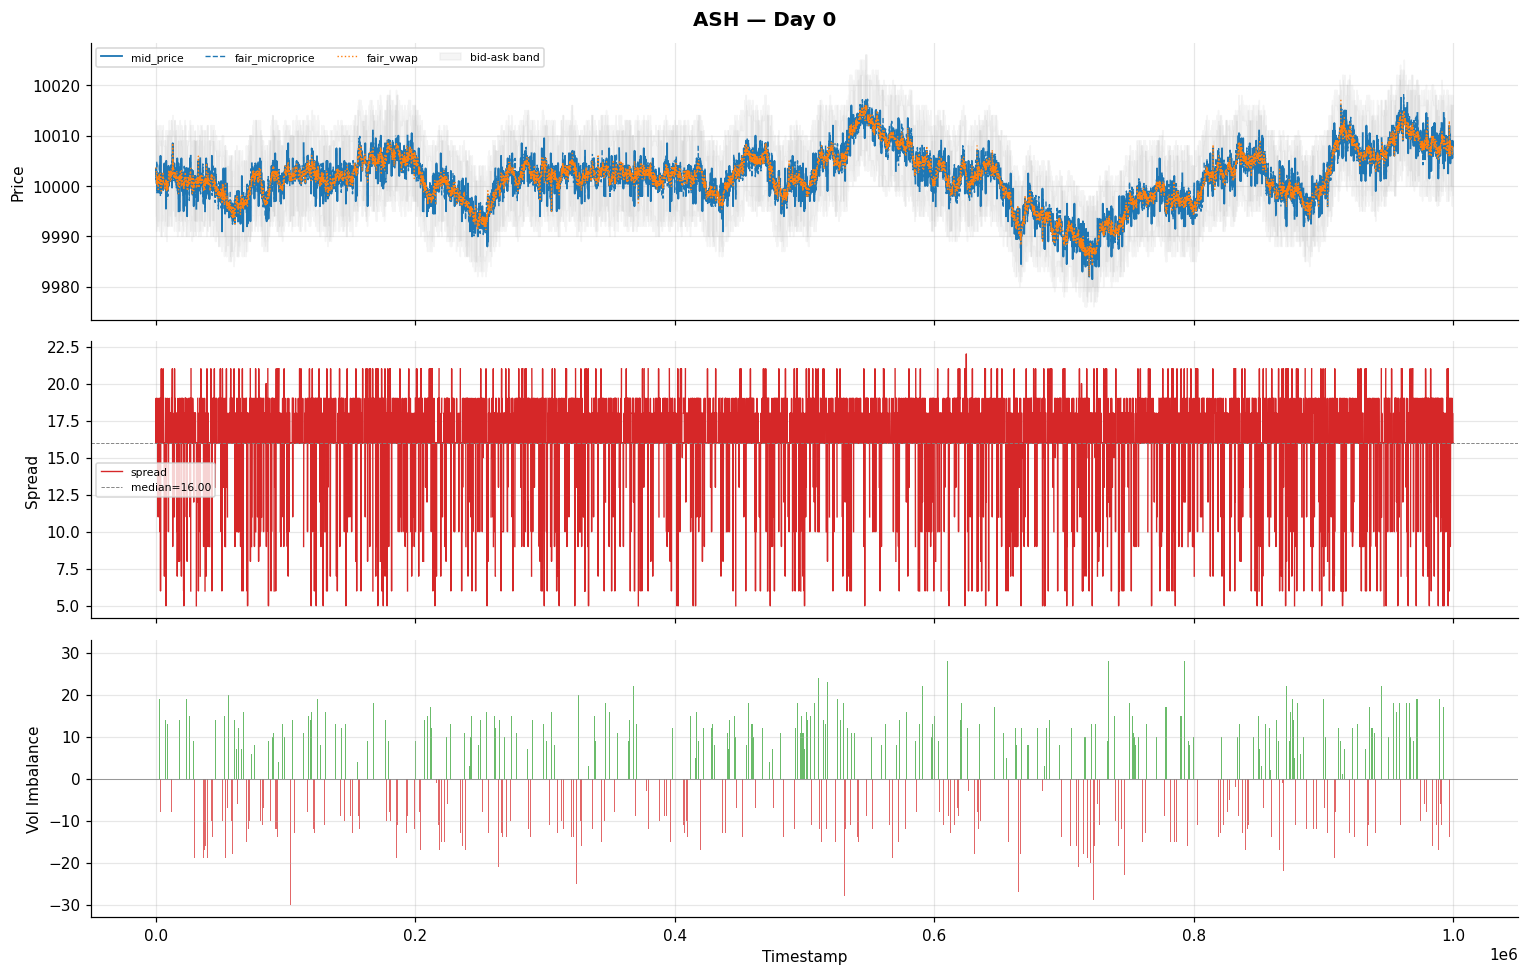

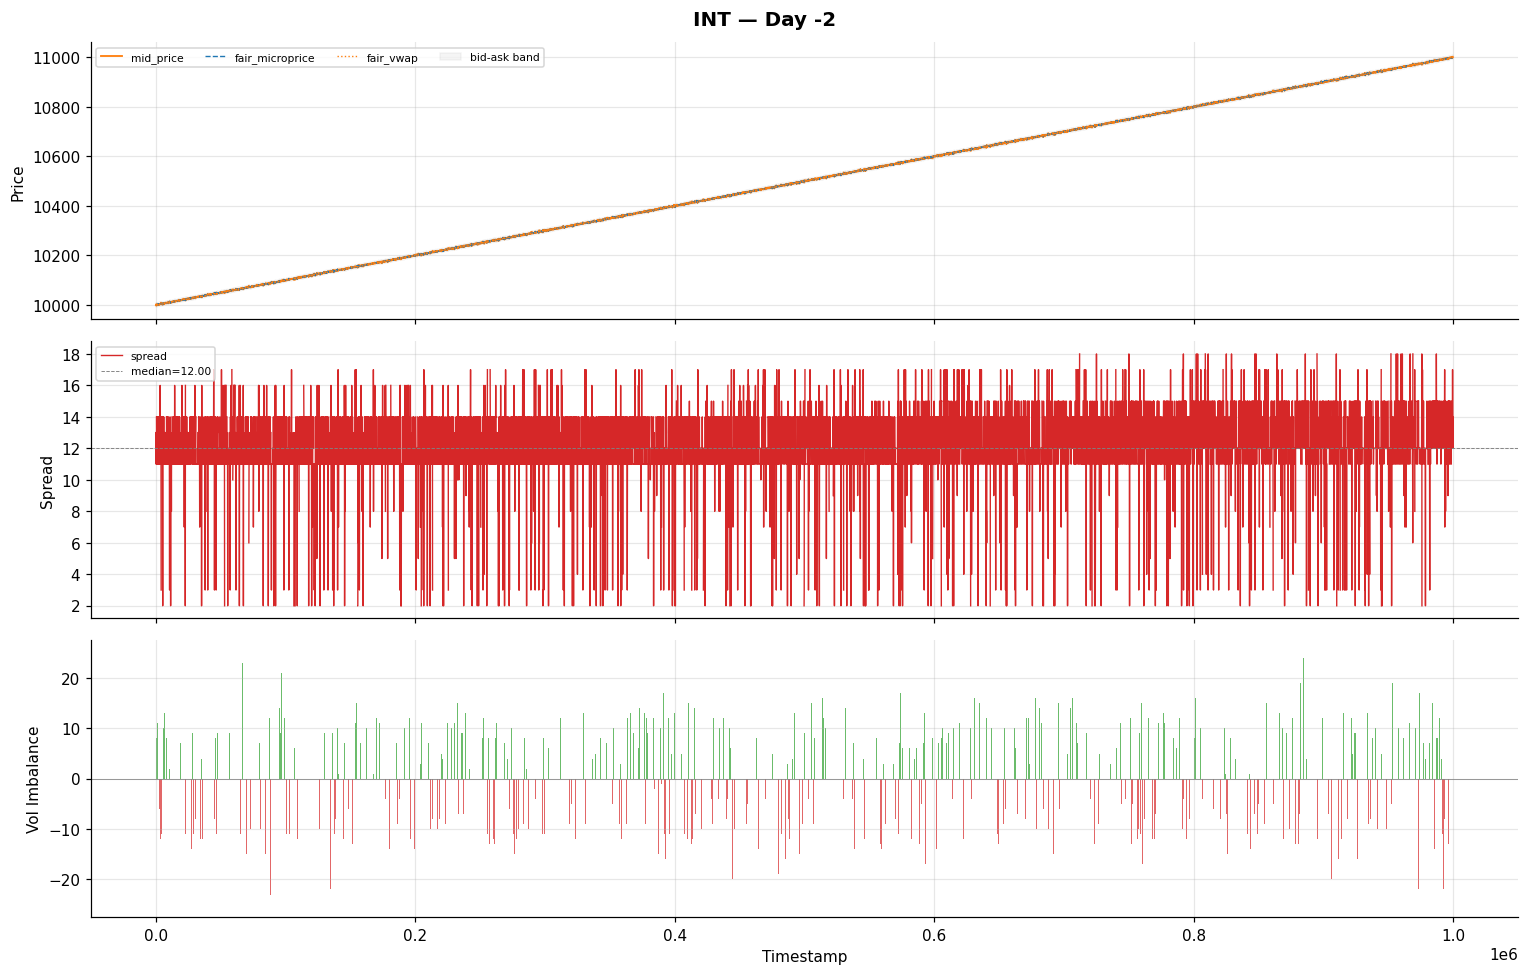

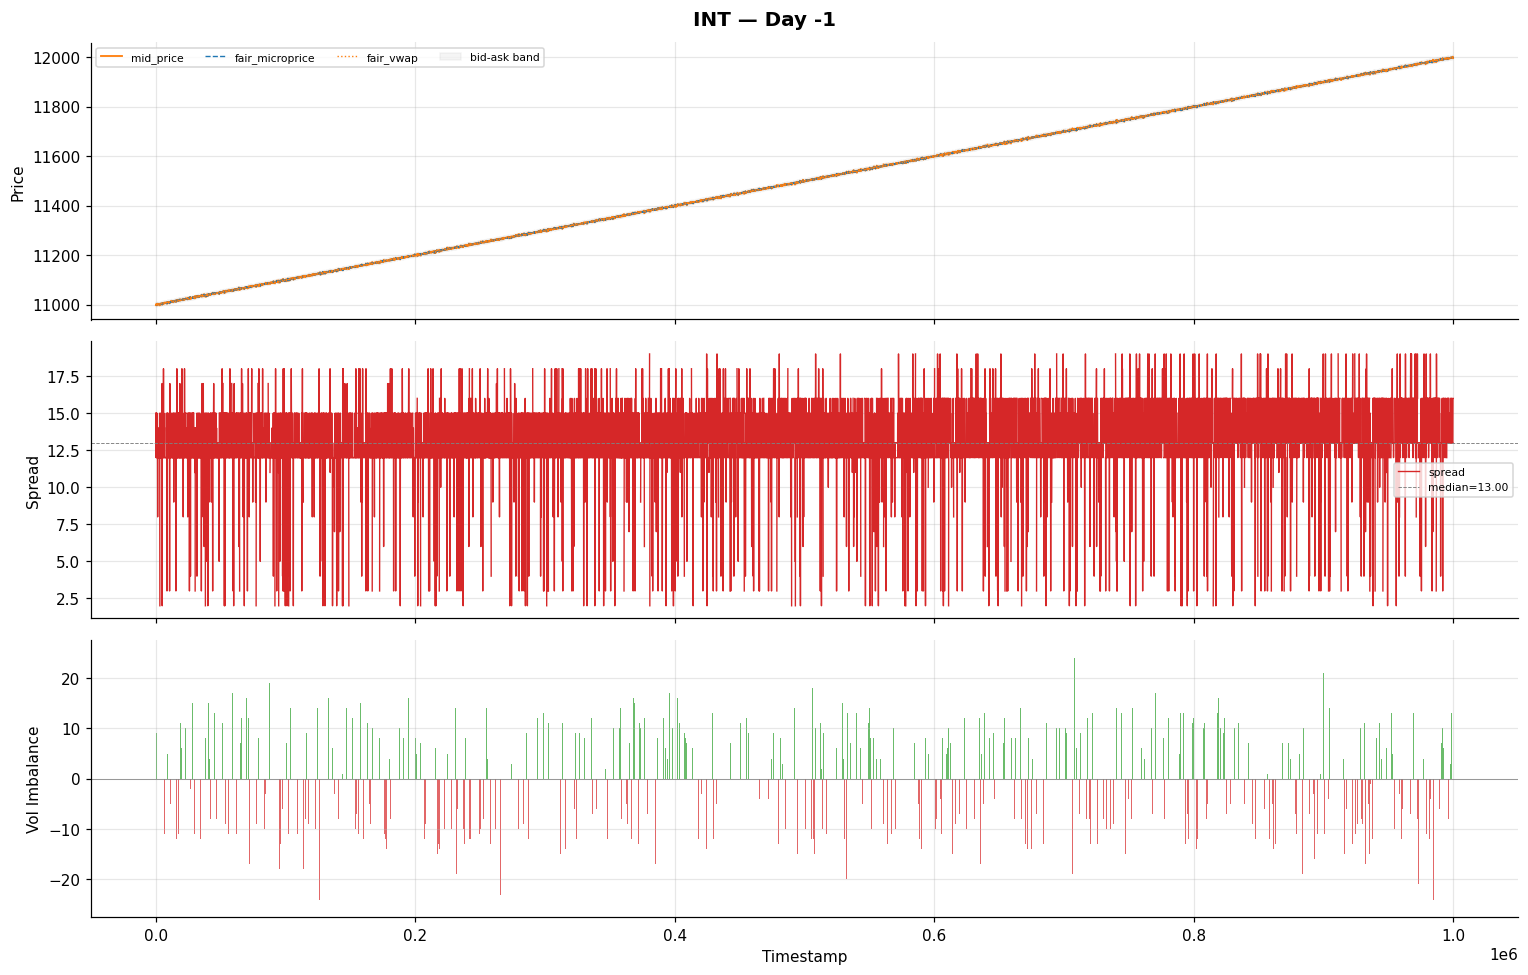

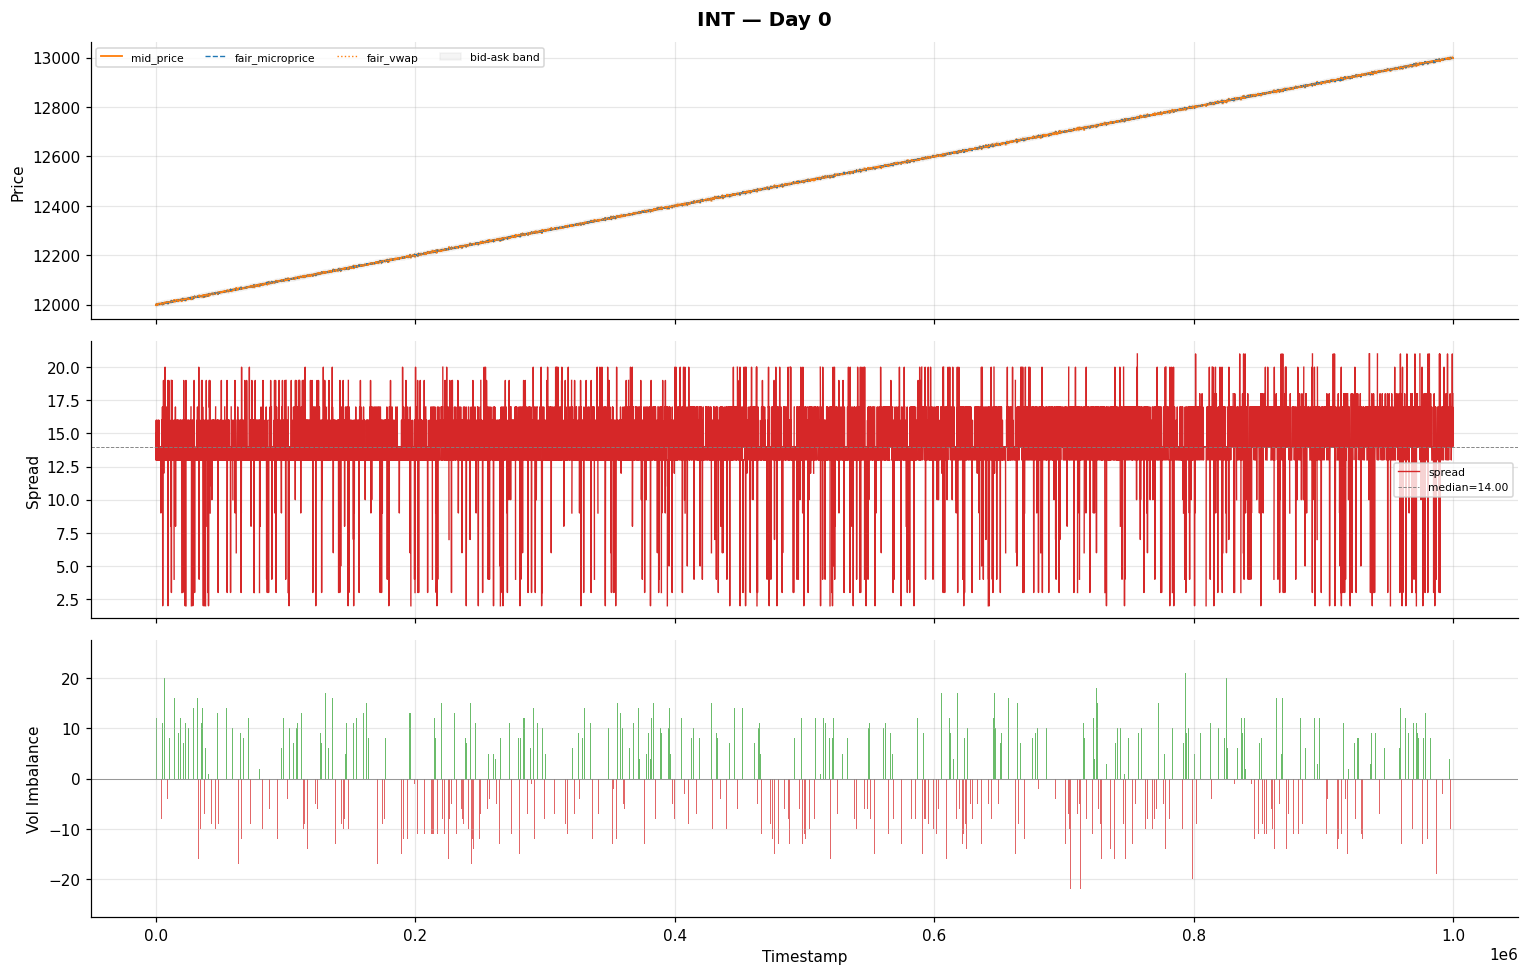

In [13]:
def plot_prices_per_day(product, day):
    """Plot mid price, fair estimators, spread, and volume imbalance for one product-day."""
    df = prices[(prices["product"] == product) & (prices["day"] == day)].copy()
    if df.empty:
        print(f"No data for {product} day {day}")
        return

    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
    fig.suptitle(f"{SHORT[product]} — Day {day}", fontsize=13, fontweight="bold")
    ts = df["timestamp"]

    # Panel 1: prices
    ax = axes[0]
    ax.plot(ts, df["mid_price"], lw=1.2, label="mid_price", color=COLORS[product])
    for est, ls in [("fair_microprice", "--"), ("fair_vwap", ":")]:
        if est in df.columns:
            ax.plot(ts, df[est], lw=0.9, ls=ls, label=est)
    if bid1_col:
        ax.fill_between(ts, df[bid1_col], df[ask1_col], alpha=0.08, color="grey", label="bid-ask band")
    ax.set_ylabel("Price")
    ax.legend(fontsize=7, ncol=4, loc="upper left")

    # Panel 2: spread
    ax = axes[1]
    if "spread" in df.columns:
        ax.plot(ts, df["spread"], lw=0.9, color="tab:red", label="spread")
        ax.axhline(df["spread"].median(), ls="--", lw=0.6, color="grey",
                   label=f"median={df['spread'].median():.2f}")
    ax.set_ylabel("Spread")
    ax.legend(fontsize=7)

    # Panel 3: volume imbalance
    ax = axes[2]
    if "volume_imbalance" in df.columns:
        c = np.where(df["volume_imbalance"] >= 0, "#2ca02c", "#d62728")
        ax.bar(ts, df["volume_imbalance"], width=(ts.diff().median() or 50) * 0.8,
               color=c, alpha=0.7)
    ax.axhline(0, color="grey", lw=0.5)
    ax.set_ylabel("Vol Imbalance")
    ax.set_xlabel("Timestamp")

    plt.tight_layout()
    plt.show()


for prod in PRODUCTS:
    for d in sorted(prices["day"].unique()):
        plot_prices_per_day(prod, d)

## 7 — Overlay All Days

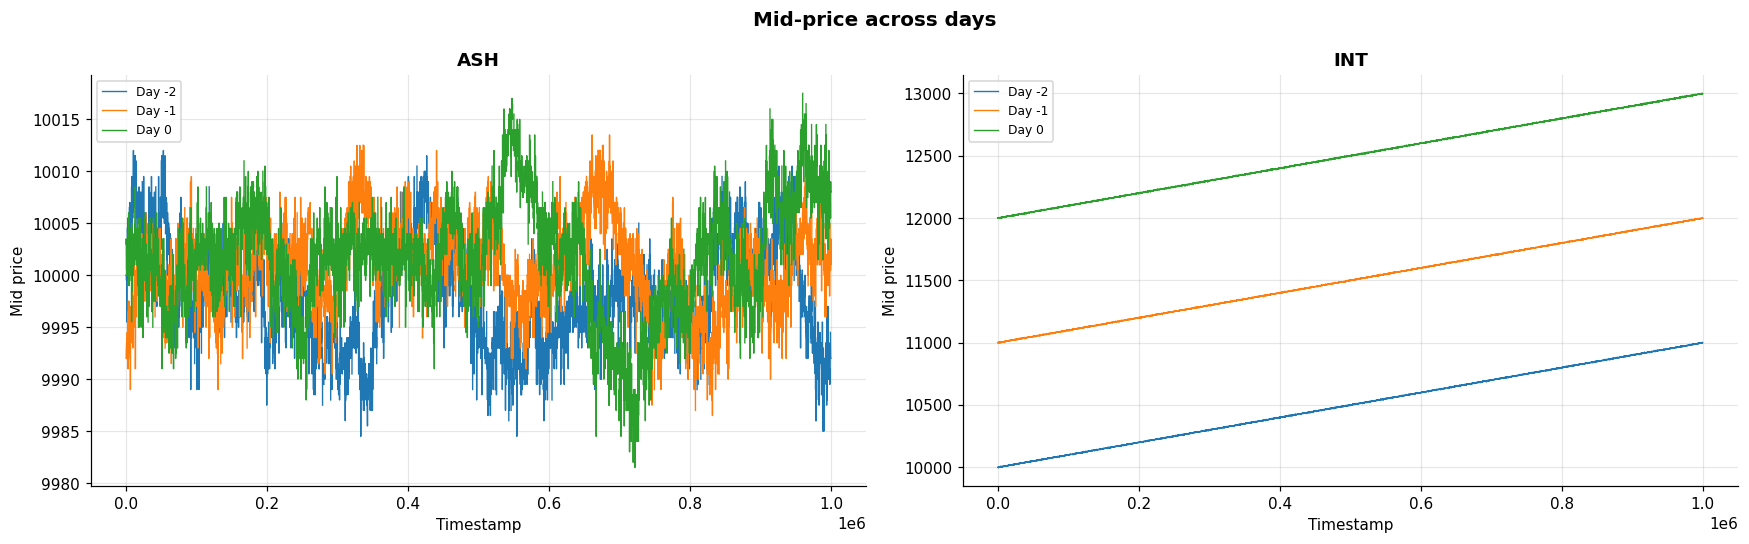

In [14]:
fig, axes = plt.subplots(1, len(PRODUCTS), figsize=(16, 5), sharey=False)
if len(PRODUCTS) == 1:
    axes = [axes]

for ax, prod in zip(axes, PRODUCTS):
    sub = prices[prices["product"] == prod]
    for d in sorted(sub["day"].unique()):
        ds = sub[sub["day"] == d]
        ax.plot(ds["timestamp"], ds["mid_price"], label=f"Day {d}", lw=0.9)
    ax.set_title(SHORT[prod], fontweight="bold")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Mid price")
    ax.legend(fontsize=8)

fig.suptitle("Mid-price across days", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 8 — Return Distribution

ASH:  mean=0.000000  std=0.000185  skew=0.023  kurt=3.430
INT:  mean=0.000009  std=0.000146  skew=0.021  kurt=4.549


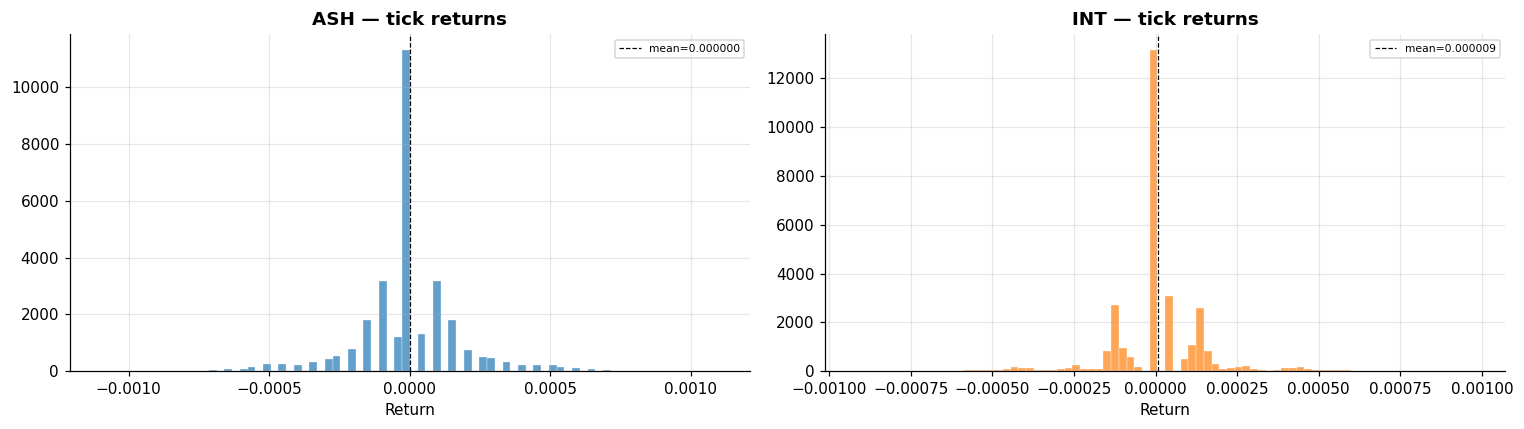

In [15]:
if "mid_return" in prices.columns:
    fig, axes = plt.subplots(1, len(PRODUCTS), figsize=(14, 4))
    if len(PRODUCTS) == 1:
        axes = [axes]

    for ax, prod in zip(axes, PRODUCTS):
        ret = prices.loc[prices["product"] == prod, "mid_return"].dropna()
        ax.hist(ret, bins=80, color=COLORS[prod], alpha=0.7, edgecolor="white", lw=0.3)
        ax.axvline(ret.mean(), color="black", ls="--", lw=0.8, label=f"mean={ret.mean():.6f}")
        ax.set_title(f"{SHORT[prod]} — tick returns", fontweight="bold")
        ax.set_xlabel("Return")
        ax.legend(fontsize=7)
        print(f"{SHORT[prod]}:  mean={ret.mean():.6f}  std={ret.std():.6f}  "
              f"skew={ret.skew():.3f}  kurt={ret.kurtosis():.3f}")

    plt.tight_layout()
    plt.show()

## 9 — Autocorrelation of Returns

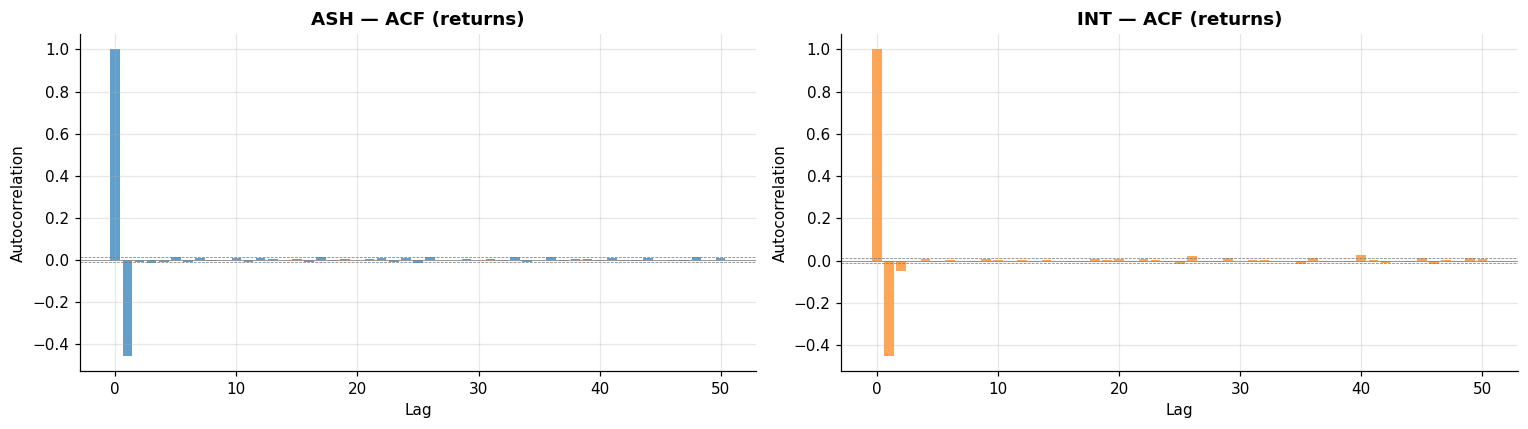

In [16]:
if "mid_return" in prices.columns:
    max_lag = 50
    fig, axes = plt.subplots(1, len(PRODUCTS), figsize=(14, 4))
    if len(PRODUCTS) == 1:
        axes = [axes]

    for ax, prod in zip(axes, PRODUCTS):
        ret = prices.loc[prices["product"] == prod, "mid_return"].dropna().values
        acf = [np.corrcoef(ret[lag:], ret[:-lag])[0, 1] if lag > 0 else 1.0
               for lag in range(max_lag + 1)]
        ax.bar(range(max_lag + 1), acf, color=COLORS[prod], alpha=0.7, width=0.8)
        ax.axhline(0, color="grey", lw=0.5)
        ax.axhline( 1.96 / np.sqrt(len(ret)), color="grey", ls="--", lw=0.5)
        ax.axhline(-1.96 / np.sqrt(len(ret)), color="grey", ls="--", lw=0.5)
        ax.set_title(f"{SHORT[prod]} — ACF (returns)", fontweight="bold")
        ax.set_xlabel("Lag")
        ax.set_ylabel("Autocorrelation")

    plt.tight_layout()
    plt.show()

## 10 — Spread Analysis

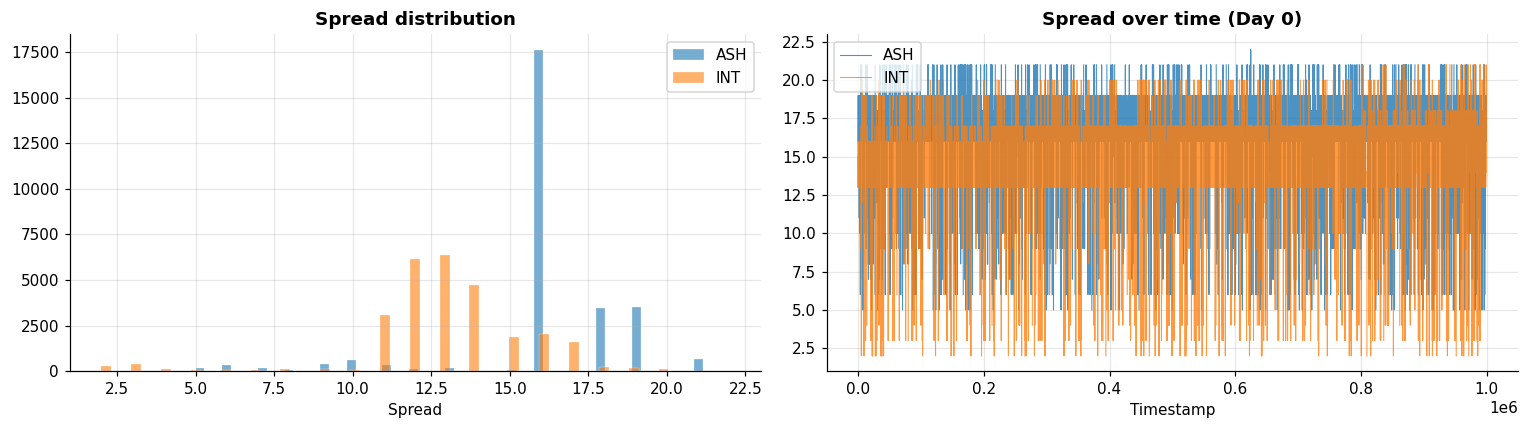

In [17]:
if "spread" in prices.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Distribution
    for prod in PRODUCTS:
        sp = prices.loc[prices["product"] == prod, "spread"].dropna()
        axes[0].hist(sp, bins=60, alpha=0.6, label=SHORT[prod], color=COLORS[prod],
                     edgecolor="white", lw=0.3)
    axes[0].set_title("Spread distribution", fontweight="bold")
    axes[0].set_xlabel("Spread")
    axes[0].legend()

    # Over time (day 0 only)
    for prod in PRODUCTS:
        sub = prices[(prices["product"] == prod) & (prices["day"] == 0)]
        axes[1].plot(sub["timestamp"], sub["spread"], lw=0.7, label=SHORT[prod],
                     color=COLORS[prod], alpha=0.8)
    axes[1].set_title("Spread over time (Day 0)", fontweight="bold")
    axes[1].set_xlabel("Timestamp")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## 11 — Volume Imbalance vs Future Price Move

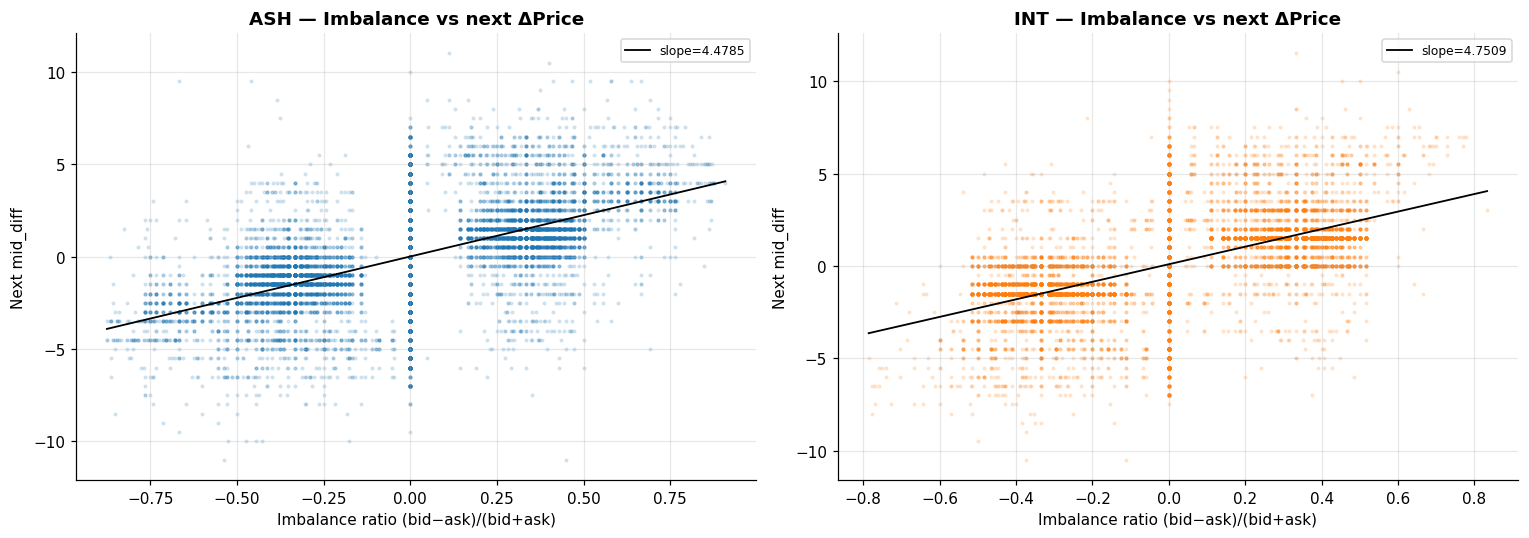

In [18]:
if "imbalance_ratio" in prices.columns and "mid_diff" in prices.columns:
    fig, axes = plt.subplots(1, len(PRODUCTS), figsize=(14, 5))
    if len(PRODUCTS) == 1:
        axes = [axes]

    for ax, prod in zip(axes, PRODUCTS):
        sub = prices[prices["product"] == prod].dropna(subset=["imbalance_ratio", "mid_diff"])
        # Future 1-step price change
        future = sub["mid_diff"].shift(-1)
        mask = future.notna()
        ax.scatter(sub.loc[mask, "imbalance_ratio"], future[mask],
                   s=3, alpha=0.15, color=COLORS[prod])
        ax.set_title(f"{SHORT[prod]} — Imbalance vs next ΔPrice", fontweight="bold")
        ax.set_xlabel("Imbalance ratio (bid−ask)/(bid+ask)")
        ax.set_ylabel("Next mid_diff")
        # OLS fit line
        x, y = sub.loc[mask, "imbalance_ratio"].values, future[mask].values
        if len(x) > 10:
            m, b = np.polyfit(x, y, 1)
            xs = np.linspace(x.min(), x.max(), 100)
            ax.plot(xs, m * xs + b, color="black", lw=1.2,
                    label=f"slope={m:.4f}")
            ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

## 12 — Trade Analysis

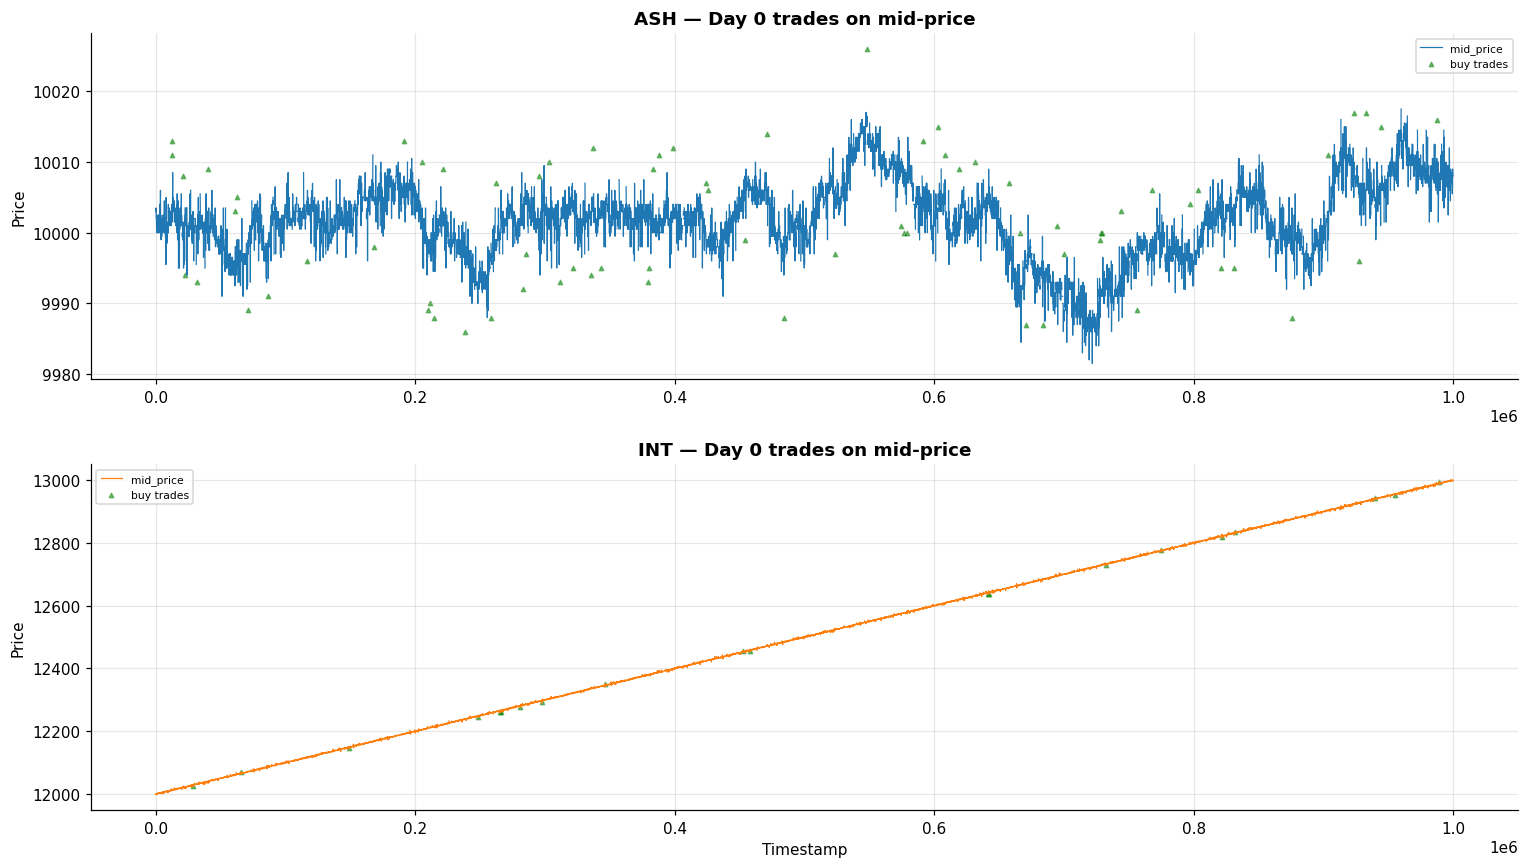

In [19]:
# ── Trade price vs mid-price (where possible) ────────────────


thresh = 7


if "price" in trades.columns:
    fig, axes = plt.subplots(len(PRODUCTS), 1, figsize=(14, 4 * len(PRODUCTS)), sharex=False)
    if len(PRODUCTS) == 1:
        axes = [axes]

    for ax, prod in zip(axes, PRODUCTS):
        tr = trades[(trades["symbol"] == prod) & (trades["day"] == 0)]
        pr = prices[(prices["product"] == prod) & (prices["day"] == 0)]

        ax.plot(pr["timestamp"], pr["mid_price"], lw=0.8, color=COLORS[prod], label="mid_price")
        if "quantity" in tr.columns:
            bt  = tr[tr["quantity"] > thresh] if "quantity" in tr.columns else tr
            if not bt.empty:
                ax.scatter(bt["timestamp"], bt["price"], s=8, marker="^",
                           color="green", alpha=0.5, label="buy trades")
        else:
            ax.scatter(tr["timestamp"], tr["price"], s=6, color="grey", alpha=0.5, label="trades")

        ax.set_title(f"{SHORT[prod]} — Day 0 trades on mid-price", fontweight="bold")
        ax.set_ylabel("Price")
        ax.legend(fontsize=7)

    axes[-1].set_xlabel("Timestamp")
    plt.tight_layout()
    plt.show()

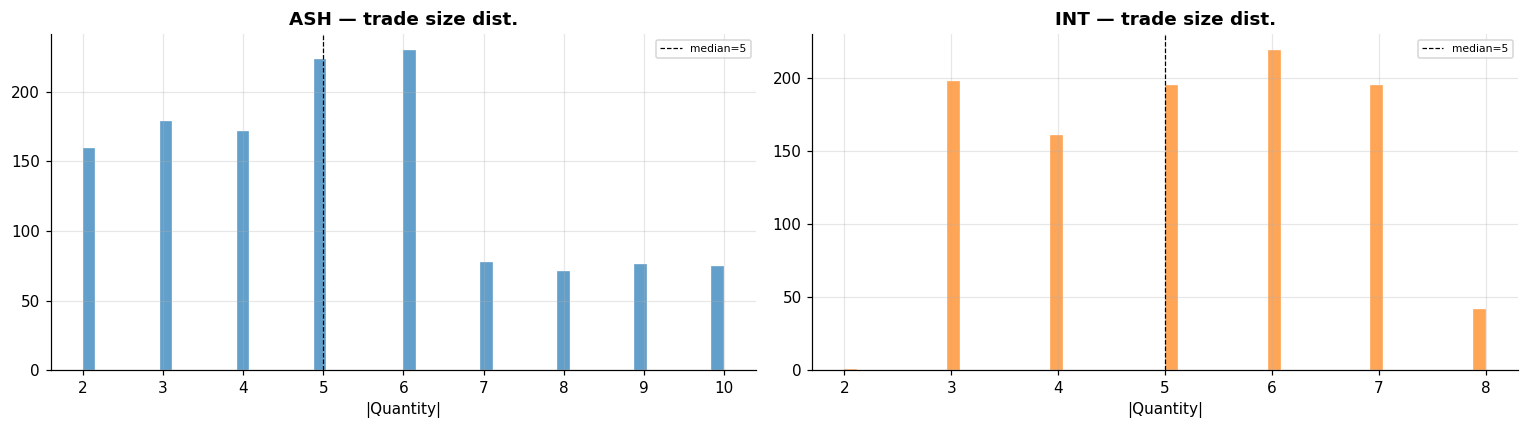

In [20]:
# ── Trade size distribution ──────────────────────────────────
if "quantity" in trades.columns:
    fig, axes = plt.subplots(1, len(PRODUCTS), figsize=(14, 4))
    if len(PRODUCTS) == 1:
        axes = [axes]

    for ax, prod in zip(axes, PRODUCTS):
        q = trades.loc[trades["symbol"] == prod, "quantity"].abs()
        ax.hist(q, bins=50, color=COLORS[prod], alpha=0.7, edgecolor="white", lw=0.3)
        ax.set_title(f"{SHORT[prod]} — trade size dist.", fontweight="bold")
        ax.set_xlabel("|Quantity|")
        ax.axvline(q.median(), color="black", ls="--", lw=0.8,
                   label=f"median={q.median():.0f}")
        ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()

In [21]:
# ── Buyer/seller breakdown (if columns exist) ────────────────
buyer_col  = next((c for c in trades.columns if "buyer" in c.lower()), None)
seller_col = next((c for c in trades.columns if "seller" in c.lower()), None)

if buyer_col and seller_col:
    print("Unique buyers: ", trades[buyer_col].nunique())
    print("Unique sellers:", trades[seller_col].nunique())
    print()

    for prod in PRODUCTS:
        sub = trades[trades["symbol"] == prod]
        print(f"\n--- {SHORT[prod]} top buyers (by total |qty|) ---")
        if "quantity" in sub.columns:
            top_b = sub.groupby(buyer_col)["quantity"].apply(lambda x: x.abs().sum())\
                       .sort_values(ascending=False).head(10)
            print(top_b.to_string())
            print(f"\n--- {SHORT[prod]} top sellers ---")
            top_s = sub.groupby(seller_col)["quantity"].apply(lambda x: x.abs().sum())\
                       .sort_values(ascending=False).head(10)
            print(top_s.to_string())
else:
    print("No buyer/seller columns found — skipping counterparty analysis.")

Unique buyers:  0
Unique sellers: 0


--- ASH top buyers (by total |qty|) ---
Series([], )

--- ASH top sellers ---
Series([], )

--- INT top buyers (by total |qty|) ---
Series([], )

--- INT top sellers ---
Series([], )


## 13 — Correlation Between Products

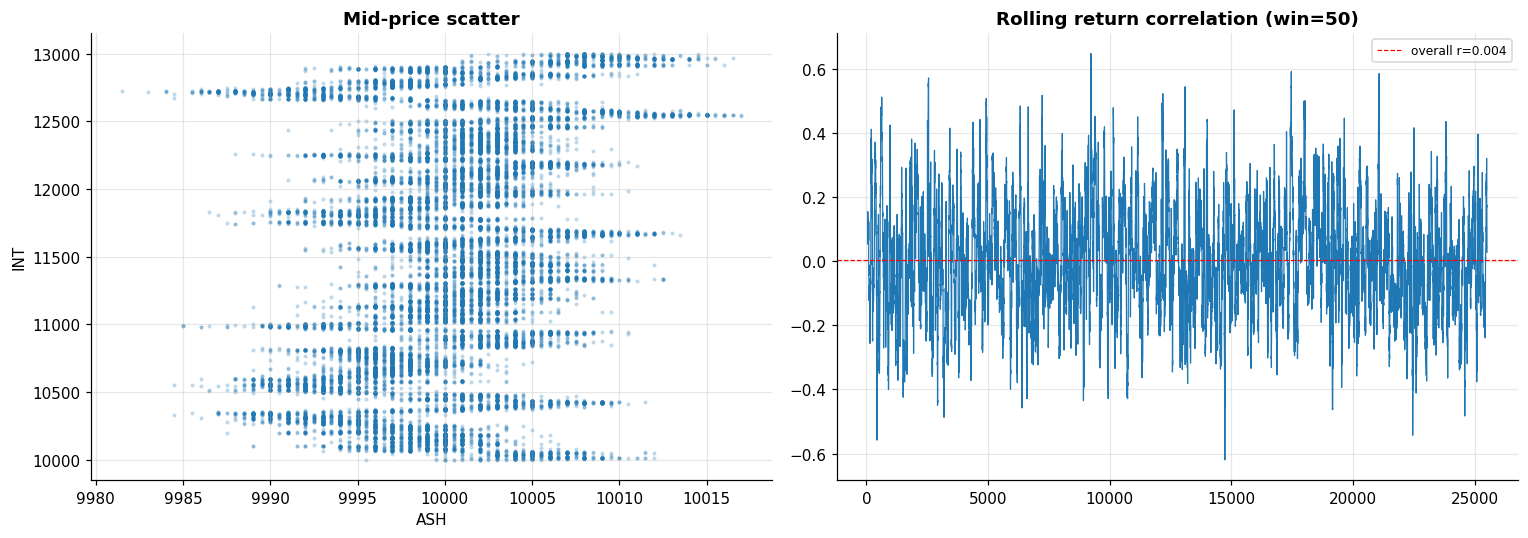

Return correlation matrix:


product,ASH_COATED_OSMIUM,INTARIAN_PEPPER_ROOT
product,,
ASH_COATED_OSMIUM,1.000000,0.004412
INTARIAN_PEPPER_ROOT,0.004412,1.000000


In [22]:
if len(PRODUCTS) >= 2 and "mid_price" in prices.columns:
    # Pivot to get mid prices side by side
    piv = prices.pivot_table(index=["day", "timestamp"], columns="product",
                              values="mid_price").dropna()

    if piv.shape[1] >= 2:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Scatter
        axes[0].scatter(piv.iloc[:, 0], piv.iloc[:, 1], s=3, alpha=0.2)
        axes[0].set_xlabel(SHORT[piv.columns[0]])
        axes[0].set_ylabel(SHORT[piv.columns[1]])
        axes[0].set_title("Mid-price scatter", fontweight="bold")

        # Rolling correlation of returns
        ret_piv = piv.pct_change().dropna()
        if len(ret_piv) > 50:
            roll_corr = ret_piv.iloc[:, 0].rolling(50).corr(ret_piv.iloc[:, 1])
            axes[1].plot(roll_corr.values, lw=0.8)
            axes[1].axhline(ret_piv.iloc[:, 0].corr(ret_piv.iloc[:, 1]),
                            color="red", ls="--", lw=0.8,
                            label=f"overall r={ret_piv.iloc[:,0].corr(ret_piv.iloc[:,1]):.3f}")
            axes[1].set_title("Rolling return correlation (win=50)", fontweight="bold")
            axes[1].legend(fontsize=8)

        plt.tight_layout()
        plt.show()

        print("Return correlation matrix:")
        display(ret_piv.corr())

## 14 — Volatility & Rolling Stats

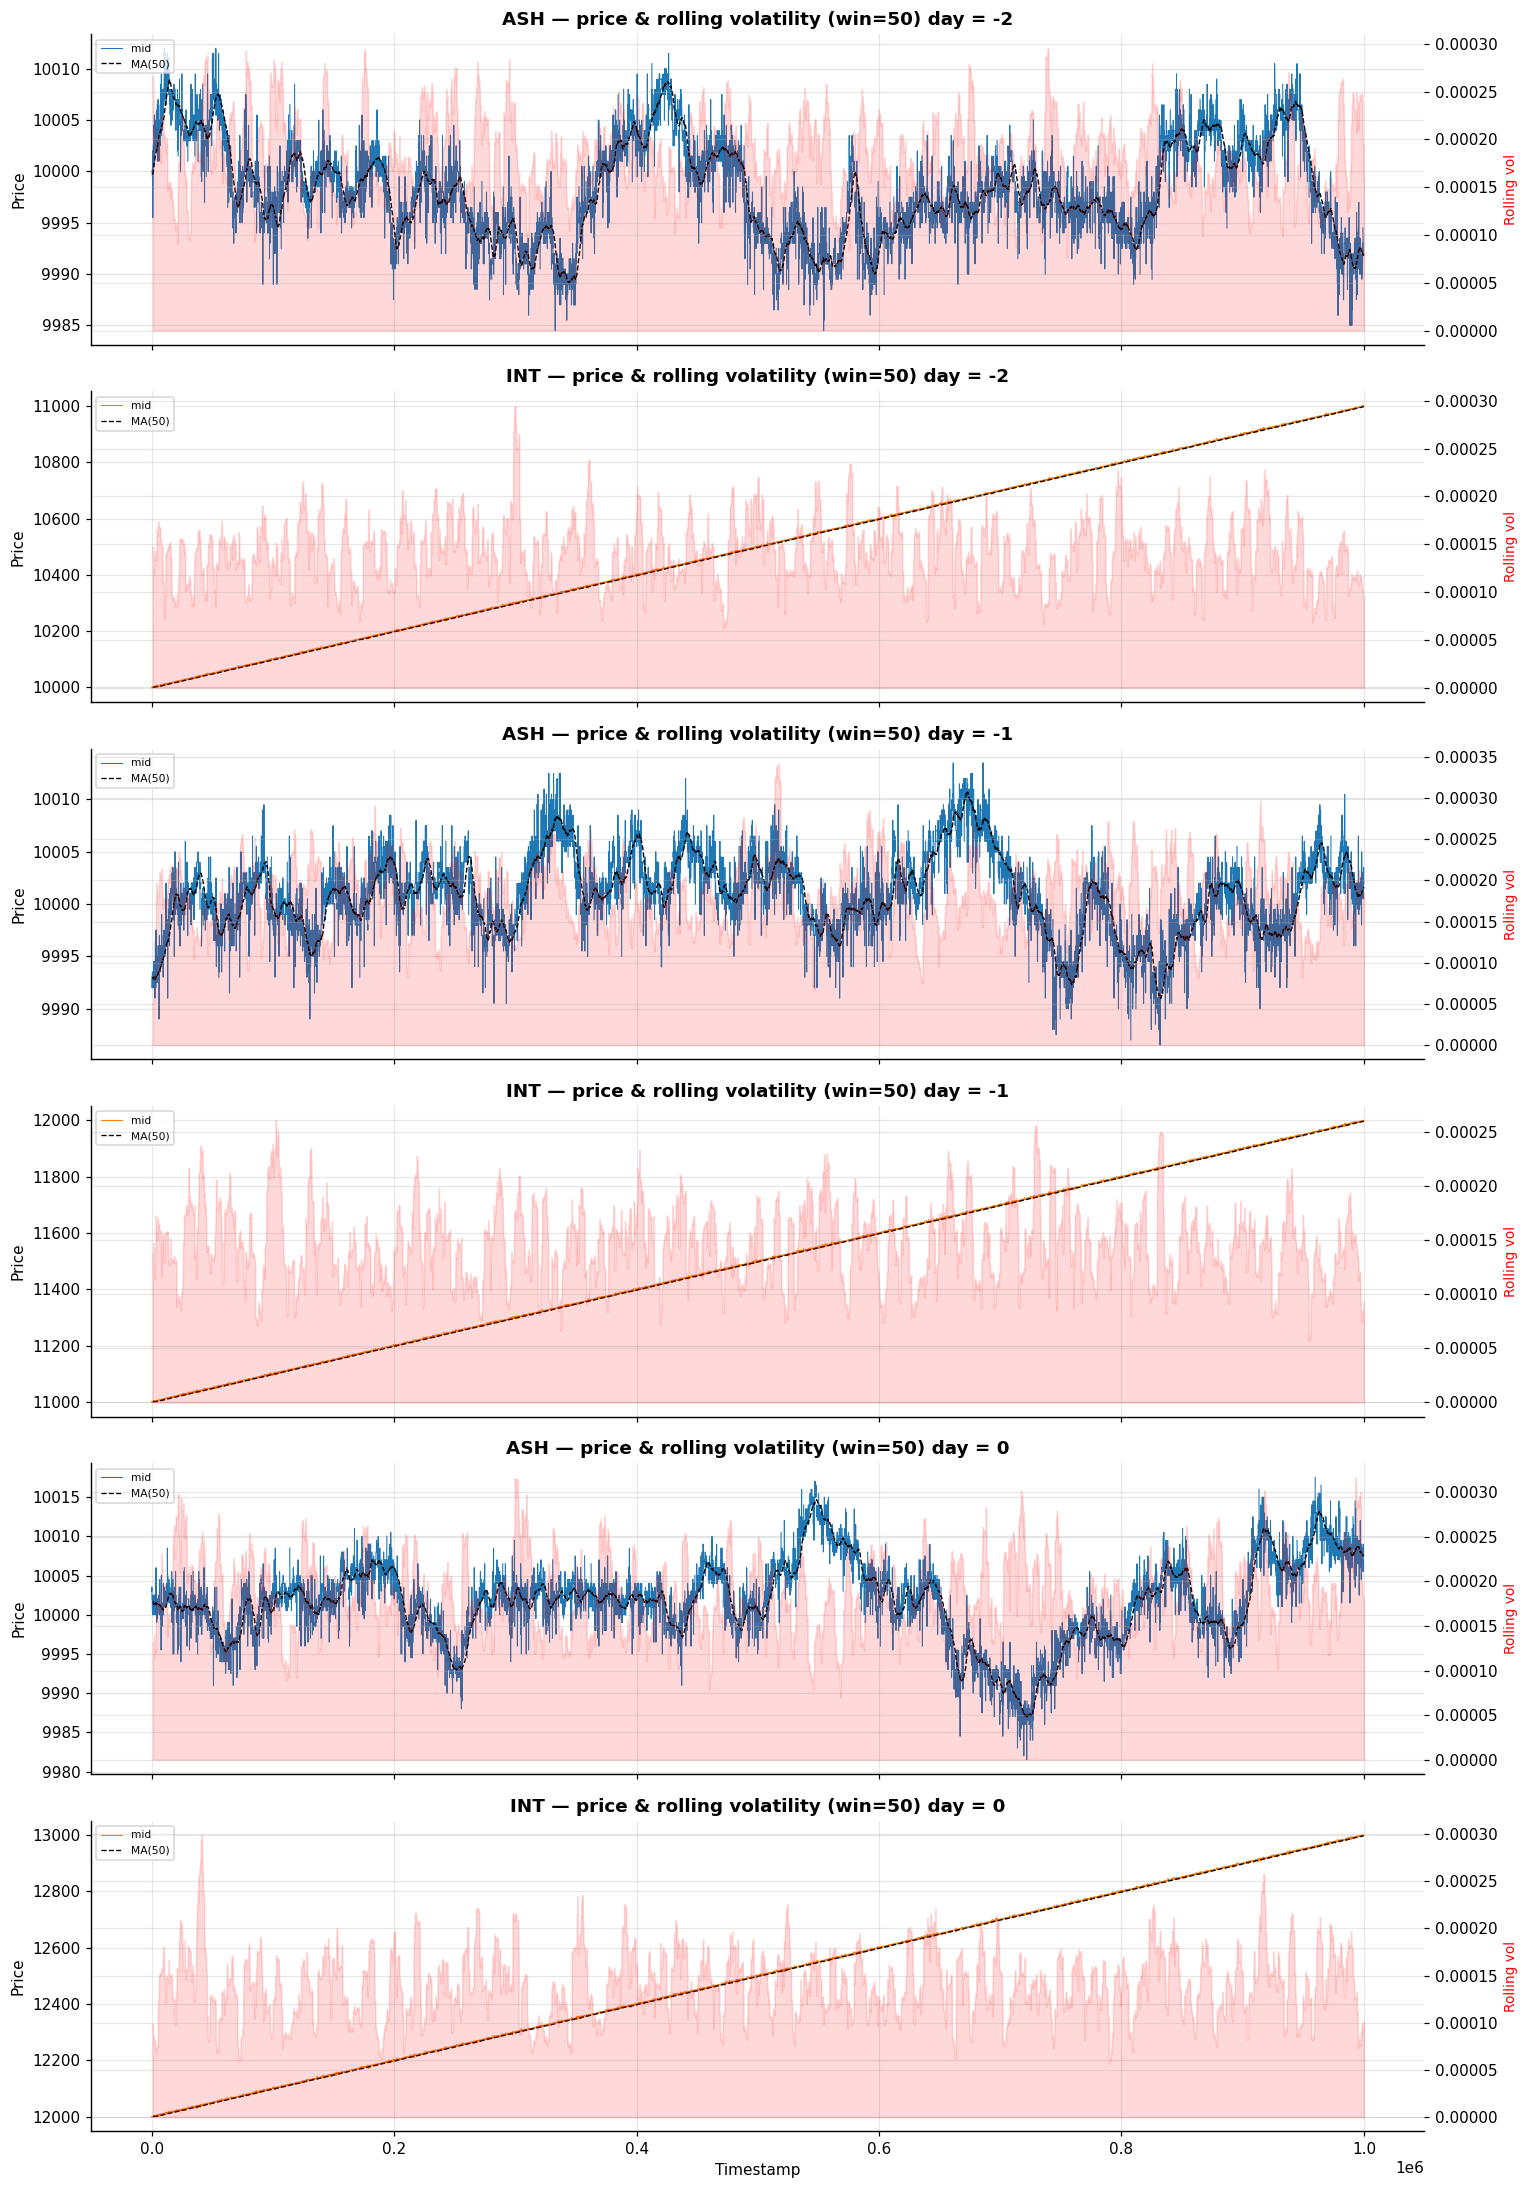

In [23]:
if "mid_return" in prices.columns:
    window = 50
    fig, axes = plt.subplots(len(PRODUCTS) * 3, 1, figsize=(14, 10 * len(PRODUCTS)), sharex=True)
    if len(PRODUCTS) == 1:
        axes = [axes]

    axes = axes.flatten()


    ind = 0

    for day in range(-2, 1):
        for prod in PRODUCTS:
            sub = prices[(prices["product"] == prod) & (prices["day"] == day)].copy()
            sub["rolling_vol"] = sub["mid_return"].transform(
                lambda x: x.rolling(window, min_periods=10).std()
            )
            sub["rolling_mean"] = sub["mid_price"].transform(
                lambda x: x.rolling(window, min_periods=10).mean()
            )

            ax2 = axes[ind].twinx()
            axes[ind].plot(sub["timestamp"], sub["mid_price"], lw=0.7, color=COLORS[prod], label="mid")
            axes[ind].plot(sub["timestamp"], sub["rolling_mean"], lw=0.9, color="black", ls="--",
                    label=f"MA({window})")
            ax2.fill_between(sub["timestamp"], 0, sub["rolling_vol"], alpha=0.15, color="red")
            ax2.set_ylabel("Rolling vol", color="red", fontsize=9)
            axes[ind].set_ylabel("Price")
            axes[ind].set_title(f"{SHORT[prod]} — price & rolling volatility (win={window}) day = {day}", fontweight="bold")
            axes[ind].legend(fontsize=7, loc="upper left")

            ind += 1

    axes[-1].set_xlabel("Timestamp")
    plt.tight_layout()
    plt.show()

## 15 — Order Book Depth (if multiple levels available)

Order book levels detected: 3
  Bid price cols: ['bid_price_1', 'bid_price_2', 'bid_price_3']
  Ask price cols: ['ask_price_1', 'ask_price_2', 'ask_price_3']
  Bid vol cols:   ['bid_volume_1', 'bid_volume_2', 'bid_volume_3']
  Ask vol cols:   ['ask_volume_1', 'ask_volume_2', 'ask_volume_3']


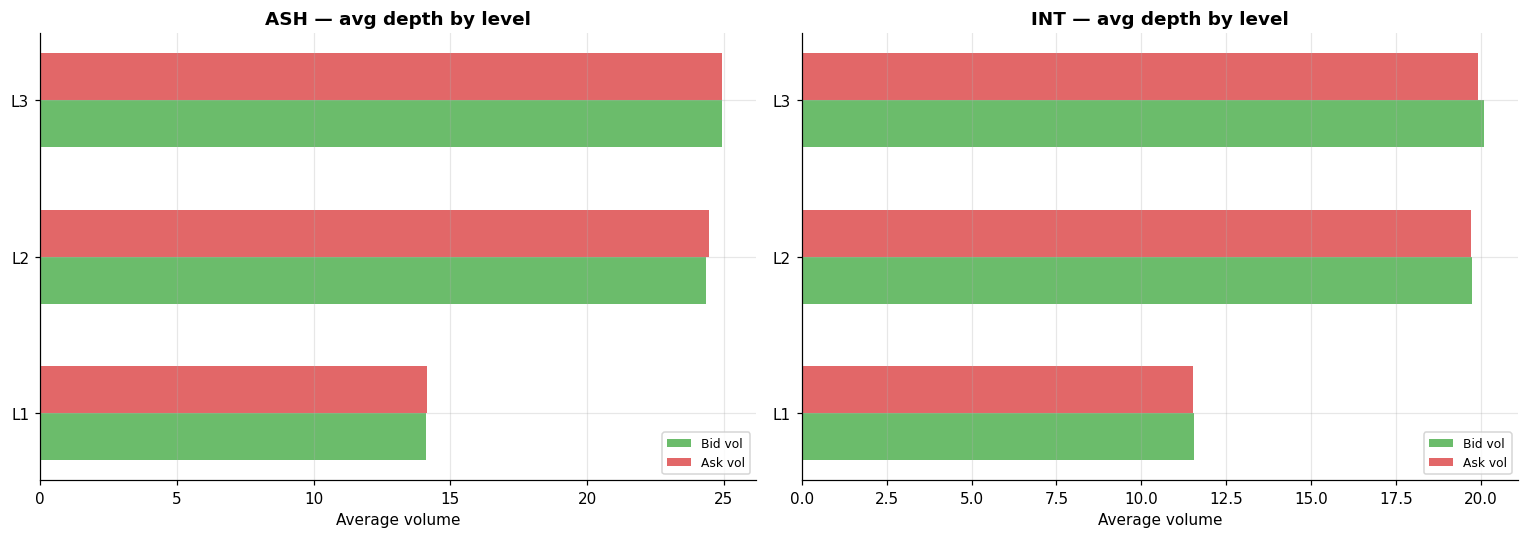

In [24]:
bid_price_cols  = sorted([c for c in prices.columns if 'bid_price' in c.lower()])
ask_price_cols  = sorted([c for c in prices.columns if 'ask_price' in c.lower()])
bid_vol_cols    = sorted([c for c in prices.columns if 'bid_volume' in c.lower() or 'bid_vol' in c.lower()])
ask_vol_cols    = sorted([c for c in prices.columns if 'ask_volume' in c.lower() or 'ask_vol' in c.lower()])

n_levels = min(len(bid_price_cols), len(ask_price_cols))
print(f"Order book levels detected: {n_levels}")
print(f"  Bid price cols: {bid_price_cols}")
print(f"  Ask price cols: {ask_price_cols}")
print(f"  Bid vol cols:   {bid_vol_cols}")
print(f"  Ask vol cols:   {ask_vol_cols}")

if n_levels >= 2:
    # Snapshot: average depth profile
    fig, axes = plt.subplots(1, len(PRODUCTS), figsize=(14, 5))
    if len(PRODUCTS) == 1:
        axes = [axes]

    for ax, prod in zip(axes, PRODUCTS):
        sub = prices[prices["product"] == prod]
        bid_vols = [sub[c].abs().mean() for c in bid_vol_cols[:n_levels]]
        ask_vols = [sub[c].abs().mean() for c in ask_vol_cols[:n_levels]]

        levels = np.arange(1, n_levels + 1)
        ax.barh(levels - 0.15, bid_vols, height=0.3, color="#2ca02c", alpha=0.7, label="Bid vol")
        ax.barh(levels + 0.15, ask_vols, height=0.3, color="#d62728", alpha=0.7, label="Ask vol")
        ax.set_yticks(levels)
        ax.set_yticklabels([f"L{i}" for i in levels])
        ax.set_xlabel("Average volume")
        ax.set_title(f"{SHORT[prod]} — avg depth by level", fontweight="bold")
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

## 16 — Intraday Patterns (timestamp bins)

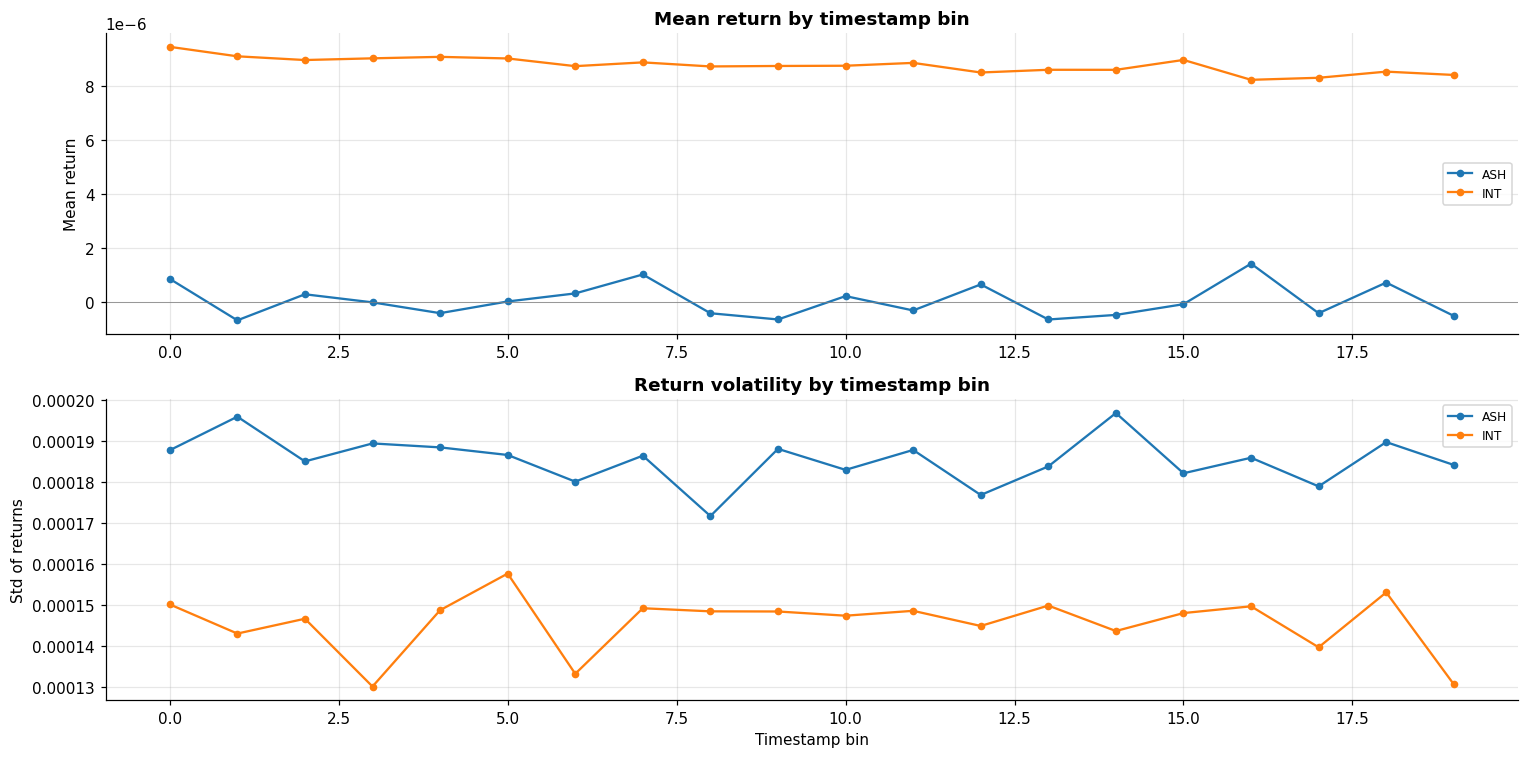

In [25]:
if "mid_return" in prices.columns:
    n_bins = 20
    prices["ts_bin"] = pd.cut(prices["timestamp"], bins=n_bins, labels=False)

    fig, axes = plt.subplots(2, 1, figsize=(14, 7))

    for prod in PRODUCTS:
        sub = prices[prices["product"] == prod]
        grp = sub.groupby("ts_bin")["mid_return"]

        mean_ret = grp.mean()
        vol_ret  = grp.std()

        axes[0].plot(mean_ret.index, mean_ret.values, marker="o", ms=4,
                     label=SHORT[prod], color=COLORS[prod])
        axes[1].plot(vol_ret.index, vol_ret.values, marker="o", ms=4,
                     label=SHORT[prod], color=COLORS[prod])

    axes[0].axhline(0, color="grey", lw=0.5)
    axes[0].set_title("Mean return by timestamp bin", fontweight="bold")
    axes[0].set_ylabel("Mean return")
    axes[0].legend(fontsize=8)

    axes[1].set_title("Return volatility by timestamp bin", fontweight="bold")
    axes[1].set_ylabel("Std of returns")
    axes[1].set_xlabel("Timestamp bin")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    prices.drop(columns=["ts_bin"], inplace=True)

## 17 — Fair-Price Estimator Comparison

In [26]:
fair_cols = [c for c in prices.columns if c.startswith("fair_")]
if fair_cols and "mid_return" in prices.columns:
    # Compare how well each estimator predicts next-tick direction
    results = []
    for prod in PRODUCTS:
        sub = prices[prices["product"] == prod].copy()
        future_ret = sub["mid_price"].shift(-1) - sub["mid_price"]
        for fc in fair_cols:
            signal = sub[fc] - sub["mid_price"]  # if fair > mid => expect price up
            mask = signal.notna() & future_ret.notna() & (signal != 0)
            if mask.sum() < 20:
                continue
            correct = ((signal[mask] > 0) & (future_ret[mask] > 0)) | \
                      ((signal[mask] < 0) & (future_ret[mask] < 0))
            hit_rate = correct.mean()
            avg_pnl  = (signal[mask].apply(np.sign) * future_ret[mask]).mean()
            results.append({
                "product": SHORT[prod], "estimator": fc,
                "hit_rate": f"{hit_rate:.3f}",
                "avg_edge": f"{avg_pnl:.6f}",
                "n_signals": int(mask.sum())
            }) 

    if results:
        res_df = pd.DataFrame(results)
        display(res_df)
    else:
        print("Not enough signal variance to evaluate.")

,product,estimator,hit_rate,avg_edge,n_signals
0,ASH,fair_microprice,0.887,1.905627,8530
1,ASH,fair_vwap,0.490,0.713540,22710
2,INT,fair_microprice,0.867,1.809281,7941
3,INT,fair_vwap,0.539,0.856789,15156


In [ ]:
from statsmodels.tsa.stattools import adfuller

def run_adf(series, name):
    s = series.dropna()
    result = adfuller(s, autolag="AIC")
    stat, pval, lags, nobs, crit, _ = result
    print(f"
{'='*55}")
    print(f"  ADF Test — {name}")
    print(f"{'='*55}")
    print(f"  Test statistic : {stat:.4f}")
    print(f"  p-value        : {pval:.4f}")
    print(f"  Lags used      : {lags}")
    print(f"  Obs used       : {nobs}")
    print("  Critical values:")
    for level, cv in crit.items():
        flag = " <-- REJECT H0" if stat < cv else ""
        print(f"    {level:>4s}  {cv:.4f}{flag}")
    conclusion = "Stationary (reject H0)" if pval < 0.05 else "Non-stationary (fail to reject H0)"
    print(f"
  Conclusion: {conclusion}  (p={'<0.001' if pval < 0.001 else f'{pval:.4f}'})")

ash = prices[prices["product"] == "ASH_COATED_OSMIUM"].sort_values(["day", "timestamp"])

# Test on mid-price level (all days)
run_adf(ash["mid_price"], "ASH mid-price (levels, all days)")

# Test on first differences
run_adf(ash["mid_price"].diff(), "ASH mid-price (1st differences, all days)")

# Per-day breakdown
for d in sorted(ash["day"].unique()):
    sub = ash[ash["day"] == d]["mid_price"]
    run_adf(sub, f"ASH mid-price (levels, day {d})")

## 18 — Key Takeaways

*(Fill in after running the notebook on real data)*

- **Price dynamics**: …
- **Spread regime**: …
- **Volume imbalance signal**: …
- **Cross-product correlation**: …
- **Best fair-price estimator**: …
- **Counterparty patterns**: …